In [33]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
print(Path.cwd())

d:\Wu\2026\Project Portfolio\002 Project\grocery_stores_access\notebooks


In [3]:
PROCESSED_DIR = Path("../data/processed")

In [4]:
stores = gpd.read_file(PROCESSED_DIR / "grocery_store_nodes.gpkg")
G = ox.load_graphml(PROCESSED_DIR / "kootenai_drive.graphml")

In [5]:
# Add travel time
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

In [6]:
# Start with one store
store = stores[
    (stores["name"] == "Super One Foods")
    & (stores["addr:city"] == "Athol")
].iloc[0]

origin_node = store["nearest_node"]

print(store["name"])
print(store["addr:city"])
print(origin_node)

Super One Foods
Athol
129686869


In [7]:
# Find reachable nodes within 10 min
reachable_nodes = nx.single_source_dijkstra_path_length(
    G,
    origin_node,
    cutoff=10 * 60,
    weight="travel_time"
)

node_ids = list(reachable_nodes.keys())

print(f"Reachable nodes: {len(node_ids):,}")

Reachable nodes: 612


In [8]:
# Convert nodes to GeoDataFrame
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

service_nodes = nodes_gdf.loc[node_ids]

In [9]:
reachable_node_set = set(node_ids)

service_edges = edges_gdf[
    edges_gdf.index.get_level_values("u").isin(reachable_node_set)
    &
    edges_gdf.index.get_level_values("v").isin(reachable_node_set)
]

In [10]:
print(len(service_edges))
service_edges.head()

1426


osmid       highway  \
u         v         key                                       
127202178 129763752 0    [13847320, 13738067]   residential   
          130532638 0                13883764  unclassified   
          130532710 0                13883765   residential   
129602288 129848349 0               720462074       primary   
          129602292 0                13839291   residential   

                                                                    name  \
u         v         key                                                    
127202178 129763752 0    [East Forest View Drive, East Forest View Road]   
          130532638 0                                 North Roberts Road   
          130532710 0                                 North Roberts Road   
129602288 129848349 0                                    East Highway 54   
          129602292 0                                   North 5th Street   

                         oneway reversed      length bridge  \
u         v         key                                       
127202178 129763752 0     False     True  860.583958    NaN   
          130532638 0     False    False  567.048681    NaN   
          130532710 0     False     True  389.667253    NaN   
129602288 129848349 0     False     True   86.500256    NaN   
          129602292 0     False    False  109.226476    NaN   

                                                                  geometry  \
u         v         key                                                      
127202178 129763752 0    LINESTRING (-116.69285 47.97717, -116.69264 47...   
          130532638 0    LINESTRING (-116.69285 47.97717, -116.69277 47...   
          130532710 0    LINESTRING (-116.69285 47.97717, -116.69313 47...   
129602288 129848349 0    LINESTRING (-116.70389 47.9478, -116.70273 47....   
          129602292 0    LINESTRING (-116.70389 47.9478, -116.70388 47....   

                         speed_kph  travel_time lanes maxspeed    ref  \
u         v         key                                                 
127202178 129763752 0    41.811521    74.096857   NaN      NaN    NaN   
          130532638 0    48.280200    42.281831   NaN      NaN    NaN   
          130532710 0    41.811521    33.550612   NaN      NaN    NaN   
129602288 129848349 0    56.326900     5.528458     2   35 mph  ID 54   
          129602292 0    41.811521     9.404473   NaN      NaN    NaN   

                        junction access  
u         v         key                  
127202178 129763752 0        NaN    NaN  
          130532638 0        NaN    NaN  
          130532710 0        NaN    NaN  
129602288 129848349 0        NaN    NaN  
          129602292 0        NaN    NaN

<Axes: >

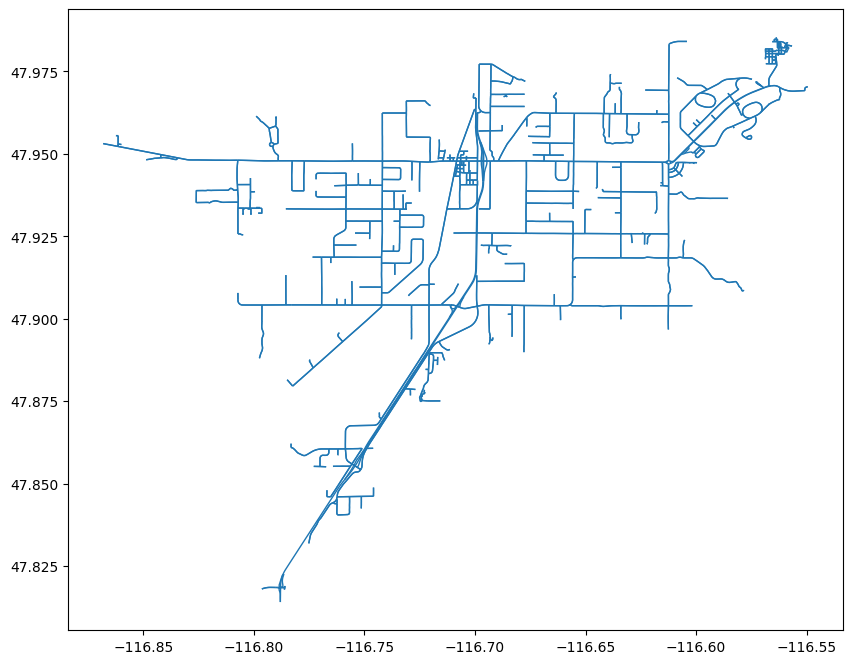

In [11]:
service_edges.plot(
    figsize=(10,10),
    linewidth=1
)

<Axes: >

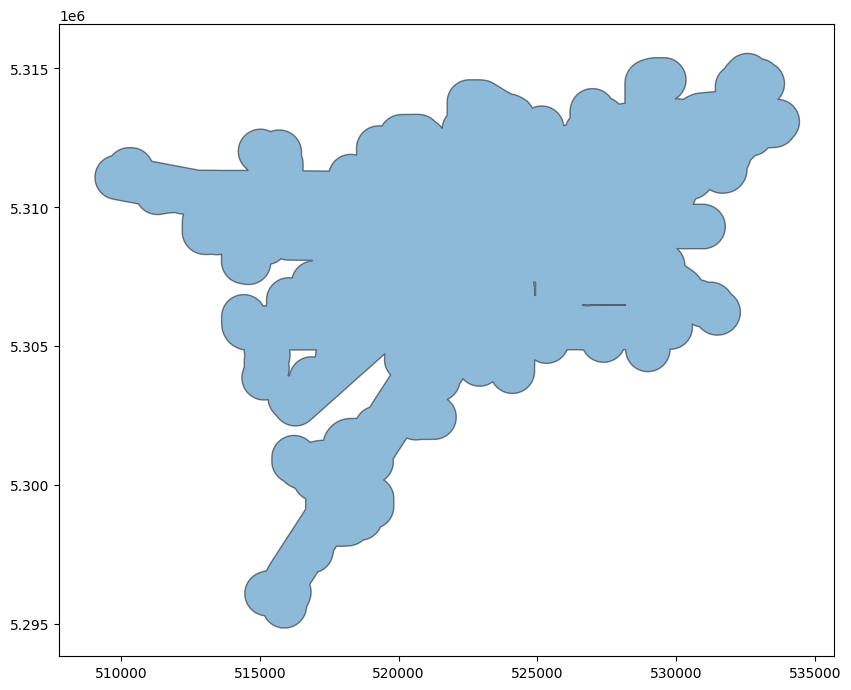

In [25]:
service_edges_utm = service_edges.to_crs(26911)

service_area = (
    service_edges_utm
    .buffer(800)
    .union_all()
)

service_area_gdf = gpd.GeoDataFrame(
    geometry=[service_area],
    crs=26911
)

service_area_gdf.plot(
    figsize=(10,10),
    alpha=0.5,
    edgecolor="black"
)

### Generate 10min, 20min, 30min Service Areas for One Store

In [26]:
def create_service_area(
    G,
    store_node,
    minutes,
    buffer_m=800,
    crs=26911
):
    reachable_nodes = nx.single_source_dijkstra_path_length(
        G,
        store_node,
        cutoff=minutes * 60,
        weight="travel_time"
    )

    node_ids = list(reachable_nodes.keys())

    nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)

    reachable_node_set = set(node_ids)

    service_edges = edges_gdf[
        edges_gdf.index.get_level_values("u").isin(reachable_node_set)
        &
        edges_gdf.index.get_level_values("v").isin(reachable_node_set)
    ]

    service_edges = service_edges.to_crs(crs)

    service_area = (
        service_edges
        .buffer(buffer_m)
        .union_all()
    )

    return gpd.GeoDataFrame(
        geometry=[service_area],
        crs=crs
    )

In [27]:
origin_node = store["nearest_node"]

service_10 = create_service_area(
    G,
    origin_node,
    minutes=10
)

service_20 = create_service_area(
    G,
    origin_node,
    minutes=20
)

service_30 = create_service_area(
    G,
    origin_node,
    minutes=30
)

C:\Users\Home_Computer\AppData\Local\Temp\ipykernel_57376\3392869359.py:36: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


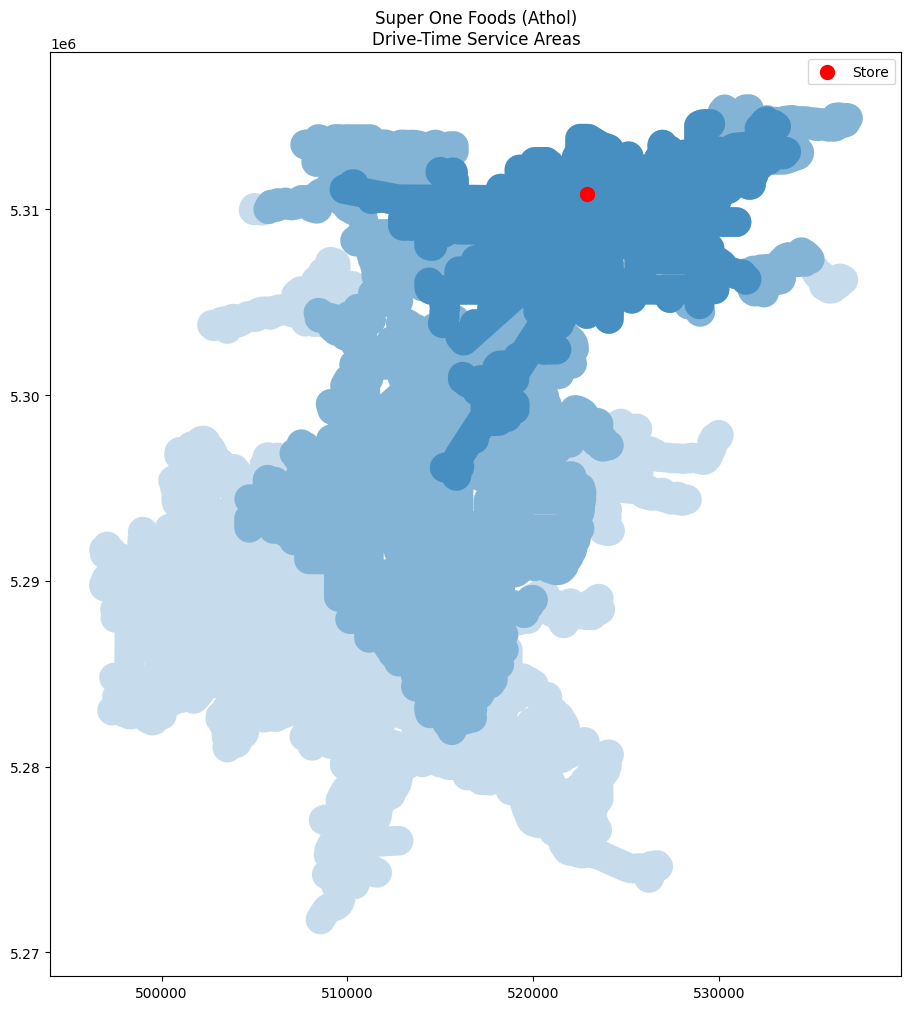

In [28]:
store_gdf = gpd.GeoDataFrame(
    [store],
    geometry="geometry",
    crs=stores.crs
).to_crs(26911)

fig, ax = plt.subplots(
    figsize=(12,12)
)

service_30.plot(
    ax=ax,
    alpha=0.25,
    label="30 min"
)

service_20.plot(
    ax=ax,
    alpha=0.40,
    label="20 min"
)

service_10.plot(
    ax=ax,
    alpha=0.60,
    label="10 min"
)

store_gdf.plot(
    ax=ax,
    color="red",
    markersize=100,
    label="Store"
)

ax.legend()

plt.title(
    f"{store['name']} ({store['addr:city']})\nDrive-Time Service Areas"
)

plt.show()

In [29]:
print("10 min area:", round(service_10.area.iloc[0] / 1e6, 2), "km²")
print("20 min area:", round(service_20.area.iloc[0] / 1e6, 2), "km²")
print("30 min area:", round(service_30.area.iloc[0] / 1e6, 2), "km²")

10 min area: 214.45 km²
20 min area: 548.43 km²
30 min area: 897.23 km²


### Create Service Areas for ALL Stores

In [30]:
service_areas = []

In [31]:
for _, store in stores.iterrows():

    print(store["name"])

    origin_node = store["nearest_node"]

    for minutes in [10, 20, 30]:

        area_gdf = create_service_area(
            G,
            origin_node,
            minutes=minutes,
            buffer_m=800
        )

        area_gdf["name"] = store["name"]
        area_gdf["city"] = store["addr:city"]
        area_gdf["minutes"] = minutes

        service_areas.append(area_gdf)

Grocery Outlet
Little Town Market
Target
Flour Mill Natural Foods
Albertsons
C & C Grocery
Safeway
Walmart Supercenter
Walmart Supercenter
Lakeside Harvest Foods
Safeway
Harrison Trading Company
Fred Meyer
Super One Foods
WinCo Foods
Natural Grocers
Yoke's
Walmart Supercenter
Super One Foods
Miller's Harvest Foods
Wenig Foods
Super One Foods
US Foods Chef's Store
Super One Foods
Pilgrim's Market
Safeway
Gittel's Grocery
Jordan's Grocery
Grocery Outlet
Trader Joe's


In [34]:
all_service_areas = pd.concat(
    service_areas,
    ignore_index=True
)

In [35]:
all_service_areas = gpd.GeoDataFrame(
    all_service_areas,
    geometry="geometry",
    crs=26911
)

In [36]:
all_service_areas.head()

,geometry,name,city,minutes
0,"POLYGON ((503268.061 5281532.66, 503190.023 52...",Grocery Outlet,Coeur d'Alene,10
1,"POLYGON ((498134.235 5278426.094, 498119.326 5...",Grocery Outlet,Coeur d'Alene,20
2,"POLYGON ((496235.593 5253261.756, 496216.463 5...",Grocery Outlet,Coeur d'Alene,30
3,"POLYGON ((512057.612 5309792.183, 512055.879 5...",Little Town Market,Athol,10
4,"POLYGON ((506809.835 5291444.637, 506738.984 5...",Little Town Market,Athol,20


In [39]:
all_service_areas.to_file(
    PROCESSED_DIR / "grocery_service_areas.gpkg",
    driver="GPKG"
)

In [40]:
service10 = all_service_areas[
    all_service_areas["minutes"] == 10
]

<Axes: >

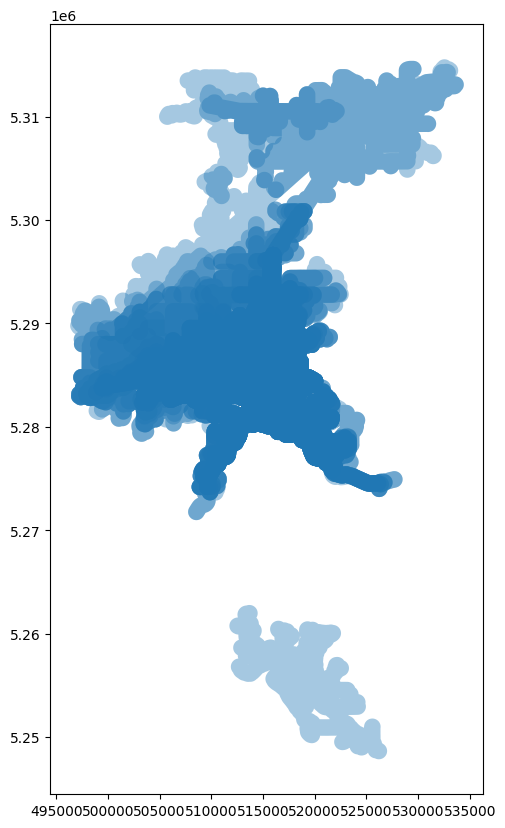

In [41]:
service10.plot(
    figsize=(10,10),
    alpha=0.4
)